In [187]:
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
dpdbo = pd.read_pickle("drive/MyDrive/Pattern-Vision/DBPattenV05.pkl")
dpdbswing = pd.read_pickle("drive/MyDrive/Pattern-Vision/DBPattenV05Swing.pkl")
dpdbnet = pd.read_pickle("drive/MyDrive/Pattern-Vision/DBPattenV05net.pkl")
dpdbio = pd.read_pickle("drive/MyDrive/Pattern-Vision/DBPattenV05io.pkl")
dpdbawt = pd.read_pickle("drive/MyDrive/Pattern-Vision/DBPattenV05awt.pkl")
dpdbargouml = pd.read_pickle("drive/MyDrive/Pattern-Vision/DBPattenV05argo.pkl")
dpdbant = pd.read_pickle("drive/MyDrive/Pattern-Vision/DBPattenV05ant.pkl")
dpdb=pd.concat([dpdbo,dpdbswing,dpdbnet,dpdbio,dpdbawt,dpdbargouml,dpdbant])

In [188]:
import matplotlib.pyplot as plt
import itertools
import numpy as np
from sklearn import svm, datasets
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier

In [189]:
def flatten_list(_2d_list):
    flat_list = []
    for element in _2d_list:
        if type(element) is list:
            for item in element:
                flat_list.append(item)
        else:
            flat_list.append(element)
    return flat_list

In [190]:
dpdb.sample(frac=1)

,Metrics,Patterns
15,"[[3, 0, 3, 118, 9, 0, 38, 0.8980263, 16, 4, 11...",State
118,"[[10, 5, 5, 77, 1, 0, 72, 0.8586957, 23, 9, 10...",Singleton
115,"[[5, 2, 3, 11, 3, 0, 18, 0.6666667, 3, 1, 2, 0...",Flyweight
5,"[[5, 0, 5, 246, 1, 2, 47, 0.95138896, 54, 12, ...",Flyweight
12,"[[15, 0, 15, 8, 3, 0, 14, 0.4, 4, 0, 4, 0, 0, ...",Strategy
...,...,...
76,"[[18, 2, 16, 8, 1, 0, 4, 0.75, 2, 0, 1, 1, 0, ...",Flyweight
82,"[[5, 3, 2, 10, 1, 0, 17, 0.5, 2, 1, 2, 0, 0, 0...",Flyweight
53,"[[1, 0, 1, 48, 1, 0, 21, 0.9150327, 36, 0, 32,...",Strategy
62,"[[1, 0, 1, 21, 2, 0, 8, 0.9358974, 13, 0, 13, ...",Flyweight


In [191]:
import tensorflow as tf
dpdb=dpdb.sample(frac=1).reset_index()

In [192]:
dpdb=dpdb.drop('index',axis=1)
dpdb=dpdb[dpdb.Metrics.map(len)>=1]
dpdb

,Metrics,Patterns
0,"[[5, 2, 3, 9, 3, 0, 14, 0.6666667, 3, 1, 2, 0,...",Flyweight
1,"[[5, 3, 2, 3, 2, 0, 6, 0.6666667, 3, 1, 2, 0, ...",Flyweight
2,"[[1, 0, 1, 168, 1, 0, 55, 0.93559325, 59, 2, 4...",State
3,"[[5, 2, 3, 7, 3, 0, 15, 0.75000006, 3, 1, 2, 0...",Flyweight
4,"[[2, 0, 2, 15, 1, 0, 9, 0.44444445, 6, 0, 5, 0...",Strategy
...,...,...
549,"[[2, 0, 2, 19, 2, 0, 12, 0.75, 4, 0, 0, 0, 2, ...",Strategy
550,"[[20, 2, 18, 760, 2, 0, 87, 0.9861111, 72, 9, ...",Flyweight
551,"[[3, 1, 2, 6, 2, 0, 6, 0.22222222, 3, 0, 1, 1,...",Strategy
552,"[[3, 2, 1, 3, 6, 0, 6, 0.0, 2, 0, 2, 0, 0, 0, ...",Strategy


In [193]:
#for i,sample in dpdb.items()
import math
for i, sample in dpdb["Metrics"].items():
  for item in sample:
    for j in range(len(item)):
      if  math.isnan(item[j]):
        item[j]=0


In [194]:
dpdb=dpdb.loc[dpdb["Patterns"]!="Mediator"]
dpdb["Patterns"].value_counts()

Flyweight                    196
Strategy                     167
Decorator                     41
State                         35
Adapter                       30
Singleton                     27
Template_Method               25
Chain_of_Responsibilities     24
Proxy                          4
Visitor                        3
Observer                       2
Name: Patterns, dtype: int64

In [195]:
def permute2(lista):
  p=lista[1]
  lista[1]=lista[2]
  lista[2]=p
  return lista

In [196]:
import numpy as np

def permute_vector(vector):
    return np.random.permutation(vector)

def permute_dataset(data):
    permuted_data = {
        "Metrics": [],
        "Patterns": []
    }
    for metrics, label in zip(data["Metrics"], data["Patterns"]):
      permuted_data["Metrics"].append(permute2(metrics))
      permuted_data["Patterns"].append(label)
      for i in range(2):
        arr = np.array(metrics)
        shifted_arr = np.roll(arr, -i+1, axis=0)
        shifted_list = shifted_arr.tolist()
        permuted_data["Metrics"].append(shifted_list)
        permuted_data["Patterns"].append(label)
        permuted_data["Metrics"].append(permute2(shifted_list))
        permuted_data["Patterns"].append(label)
    return permuted_data


permuted_data = pd.DataFrame(permute_dataset(dpdb))

print(permuted_data)
print(dpdb)
dpdb= pd.concat([dpdb,permuted_data], ignore_index=True,axis=0)

                                                Metrics   Patterns
0     [[5, 2, 3, 9, 3, 0, 14, 0.6666667, 3, 1, 2, 0,...  Flyweight
1     [[1.7471264379310345, 1.7471264379310345, 1.74...  Flyweight
2     [[1.7471264379310345, 1.7471264379310345, 1.74...  Flyweight
3     [[5.0, 2.0, 3.0, 9.0, 3.0, 0.0, 14.0, 0.666666...  Flyweight
4     [[5.0, 2.0, 3.0, 9.0, 3.0, 0.0, 14.0, 0.666666...  Flyweight
...                                                 ...        ...
2765  [[5, 2, 3, 7, 3, 0, 15, 0.75, 3, 1, 2, 0, 1, 0...  Flyweight
2766  [[2.1293103448275863, 2.1293103448275863, 2.12...  Flyweight
2767  [[2.1293103448275863, 2.1293103448275863, 2.12...  Flyweight
2768  [[5.0, 2.0, 3.0, 7.0, 3.0, 0.0, 15.0, 0.75, 3....  Flyweight
2769  [[5.0, 2.0, 3.0, 7.0, 3.0, 0.0, 15.0, 0.75, 3....  Flyweight

[2770 rows x 2 columns]
                                               Metrics   Patterns
0    [[5, 2, 3, 9, 3, 0, 14, 0.6666667, 3, 1, 2, 0,...  Flyweight
1    [[5, 3, 2, 3, 2, 0, 6, 0.6666667, 

In [197]:
dpdb["Metrics"]

0       [[5, 2, 3, 9, 3, 0, 14, 0.6666667, 3, 1, 2, 0,...
1       [[5, 3, 2, 3, 2, 0, 6, 0.6666667, 3, 1, 2, 0, ...
2       [[1, 0, 1, 168, 1, 0, 55, 0.93559325, 59, 2, 4...
3       [[5, 2, 3, 7, 3, 0, 15, 0.75000006, 3, 1, 2, 0...
4       [[2, 0, 2, 15, 1, 0, 9, 0.44444445, 6, 0, 5, 0...
                              ...                        
3319    [[5, 2, 3, 7, 3, 0, 15, 0.75, 3, 1, 2, 0, 1, 0...
3320    [[2.1293103448275863, 2.1293103448275863, 2.12...
3321    [[2.1293103448275863, 2.1293103448275863, 2.12...
3322    [[5.0, 2.0, 3.0, 7.0, 3.0, 0.0, 15.0, 0.75, 3....
3323    [[5.0, 2.0, 3.0, 7.0, 3.0, 0.0, 15.0, 0.75, 3....
Name: Metrics, Length: 3324, dtype: object

In [198]:
Unique_labels=dpdb["Patterns"].unique()

In [199]:
class_names=Unique_labels

In [200]:
labels=dpdb["Patterns"]

In [201]:
labels

0       Flyweight
1       Flyweight
2           State
3       Flyweight
4        Strategy
          ...    
3319    Flyweight
3320    Flyweight
3321    Flyweight
3322    Flyweight
3323    Flyweight
Name: Patterns, Length: 3324, dtype: object

In [202]:
bool_label=[label==Unique_labels for label in labels]

In [203]:
one_hot_label=np.array([bool.astype(int)for bool in bool_label])

In [204]:
one_hot_label[:3]


array([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [205]:
dpdbwith0=dpdb["Metrics"]
max_sample_length = max([len(sample) for sample in dpdbwith0])
zeros_list = [0] * 29

for i, sample in dpdbwith0.items():

    if len(sample) != max_sample_length:
      for j in  range(max_sample_length-len(sample)):
        dpdbwith0[i].append(zeros_list)

In [206]:
max_sample_length

3

In [207]:
dpdbwith0=dpdbwith0.apply(lambda row :flatten_list(row))
dpdbwith0

0       [5, 2, 3, 9, 3, 0, 14, 0.6666667, 3, 1, 2, 0, ...
1       [5, 3, 2, 3, 2, 0, 6, 0.6666667, 3, 1, 2, 0, 1...
2       [1, 0, 1, 168, 1, 0, 55, 0.93559325, 59, 2, 48...
3       [5, 2, 3, 7, 3, 0, 15, 0.75000006, 3, 1, 2, 0,...
4       [2, 0, 2, 15, 1, 0, 9, 0.44444445, 6, 0, 5, 0,...
                              ...                        
3319    [5, 2, 3, 7, 3, 0, 15, 0.75, 3, 1, 2, 0, 1, 0,...
3320    [2.1293103448275863, 2.1293103448275863, 2.129...
3321    [2.1293103448275863, 2.1293103448275863, 2.129...
3322    [5.0, 2.0, 3.0, 7.0, 3.0, 0.0, 15.0, 0.75, 3.0...
3323    [5.0, 2.0, 3.0, 7.0, 3.0, 0.0, 15.0, 0.75, 3.0...
Name: Metrics, Length: 3324, dtype: object

In [208]:
reformatted_df = dpdbwith0.apply(pd.Series)

In [209]:
reformatted_df.shape

(3324, 87)

In [210]:
reformatted_df= np.asarray(reformatted_df).astype('float32')

In [211]:
LabelsN=[]
for i,sample in enumerate(one_hot_label):
  for j,k in enumerate(sample):
    if sample[j]==1:
      LabelsN.append(j+1)
      break;
LabelsN=np.array(LabelsN)

In [212]:
scores=[]
precision_scores = []
recall_scores = []
f1_scores = []

In [213]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_model(data_x, data_y):
    k_fold = KFold(5, shuffle=True, random_state=1)

    predicted_targets = []
    actual_targets = []
    scores = []

    for train_ix, test_ix in k_fold.split(data_x):
        train_x, train_y, test_x, test_y = data_x[train_ix], data_y[train_ix], data_x[test_ix], data_y[test_ix]

        model = tf.keras.models.Sequential([
            tf.keras.layers.Input(shape=(87,)),
            tf.keras.layers.Dense(30, activation="relu"),
            tf.keras.layers.Dense(11, activation="softmax")
        ])

        model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

        model.fit(train_x, train_y, epochs=100, batch_size=32, verbose=0)

        _, score = model.evaluate(test_x, test_y, verbose=0)
        scores.append(score)

        predicted_labels = np.argmax(model.predict(test_x), axis=1)
        predicted_targets.extend(predicted_labels)
        actual_targets.extend(np.argmax(test_y, axis=1))

    return np.array(predicted_targets), np.array(actual_targets), scores

In [214]:
def plot_confusion_matrix(predicted_labels_list, y_test_list):
    cnf_matrix = confusion_matrix(y_test_list, predicted_labels_list)
    np.set_printoptions(precision=2)

    # Plot non-normalized confusion matrix
    plt.figure()
    generate_confusion_matrix(cnf_matrix, classes=class_names, title='Confusion matrix, without normalization')
    plt.show()

    # Plot normalized confusion matrix
    plt.figure()
    generate_confusion_matrix(cnf_matrix, classes=class_names, normalize=True, title='Normalized confusion matrix')
    plt.show()


In [215]:
dpdb["Patterns"].value_counts()

Flyweight                    1176
Strategy                     1002
Decorator                     246
State                         210
Adapter                       180
Singleton                     162
Template_Method               150
Chain_of_Responsibilities     144
Proxy                          24
Visitor                        18
Observer                       12
Name: Patterns, dtype: int64

In [216]:
import numpy as np
import itertools
import matplotlib.pyplot as plt

def generate_confusion_matrix(cnf_matrix, classes, normalize=False, title='Confusion matrix'):
    if normalize:
        cnf_matrix = cnf_matrix.astype('float') / cnf_matrix.sum(axis=1)[:, np.newaxis] * 100
        print("Normalized confusion matrix")
        fmt = '.2f'
    else:
        print('Confusion matrix, without normalization')
        fmt = 'd'

    f = plt.figure()
    f.set_figwidth(12)
    f.set_figheight(10)
    plt.imshow(cnf_matrix, interpolation='nearest', cmap=plt.get_cmap('Blues'))
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    thresh = cnf_matrix.max() / 2.

    for i, j in itertools.product(range(cnf_matrix.shape[0]), range(cnf_matrix.shape[1])):
        value = format(cnf_matrix[i, j], fmt)
        if normalize:
            value += '%'
        plt.text(j, i, value, horizontalalignment="center",
                 color="white" if cnf_matrix[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

    return cnf_matrix


21/21 [==============================] - 0s 2ms/step
Confusion matrix, without normalization


<Figure size 640x480 with 0 Axes>

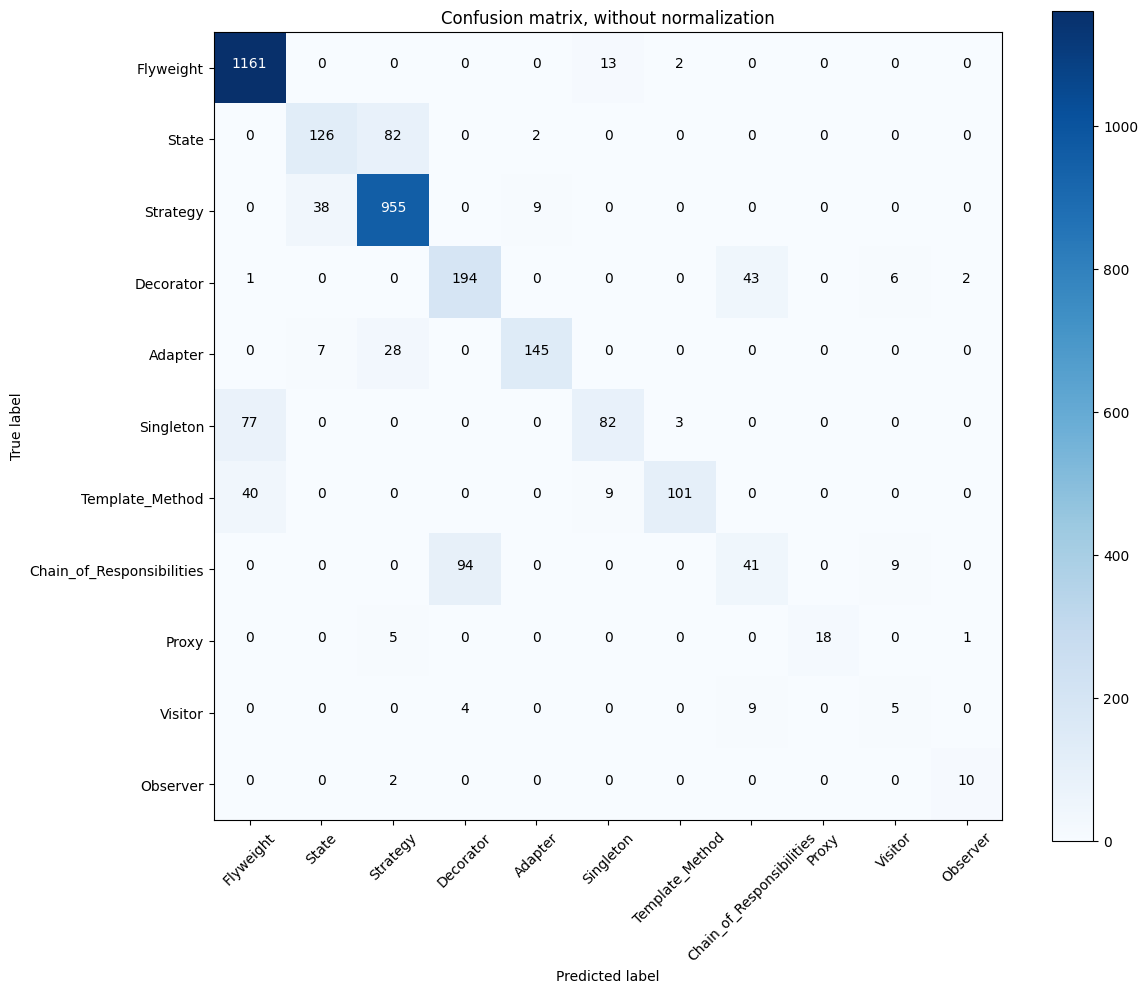

Normalized confusion matrix


<Figure size 640x480 with 0 Axes>

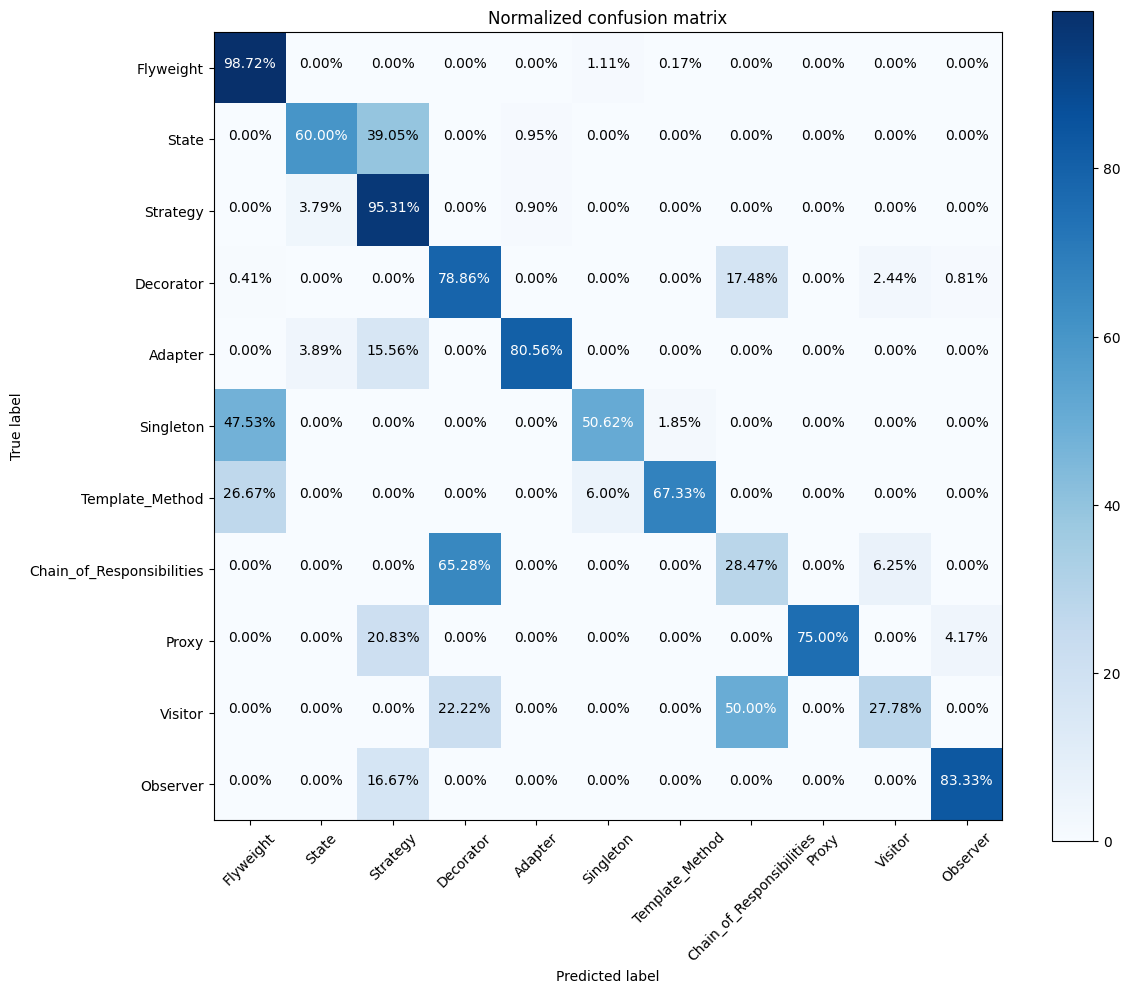

In [217]:
predicted_target, actual_target ,scores = evaluate_model(reformatted_df, one_hot_label)
plot_confusion_matrix(predicted_target, actual_target)

In [218]:
accuracy = np.mean(scores)
precision = np.mean(precision_scores, axis=0)
recall = np.mean(recall_scores, axis=0)
f1 = np.mean(f1_scores, axis=0)
accuracy,precision,recall,f1

/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


(0.8537965416908264, nan, nan, nan)